<a href="https://colab.research.google.com/github/a01068493-hash/Predicci-n-de-peso/blob/main/ODS7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto: Inteligencia Artificial para Energía Sostenible (ODS 7)Modelo de Predicción de Producción de Energía Eólica mediante Regresión Lineal

**Introducción al Problema:** El Poder del Viento
La energía eólica es una de las fuentes más importantes de energía limpia en el mundo. Aprovecha la fuerza del viento para generar electricidad sin emitir gases contaminantes.
Sin embargo, uno de los principales retos es su variabilidad.
¿Qué sucede?
La cantidad de energía generada depende de factores como la velocidad del viento, condiciones climáticas y ubicación geográfica.

**Consecuencia:**
Si no se predice correctamente la producción, puede haber desperdicio de energía, fallas en el suministro y mala planificación energética.
El Rol de la Ingeniería y los Datos
En el marco del ODS 7, el uso de datos y Machine Learning permite:
Predecir cuánta energía se generará.
Optimizar el uso de recursos energéticos.
Mejorar la estabilidad del suministro eléctrico.
Reducir la dependencia de energías no renovables.
Objetivos del Notebook
En esta sesión cubriremos el flujo completo de un proyecto de ciencia de datos:

**Carga de Datos:** Uso de Pandas para analizar el dataset de energía eólica.

**Limpieza:** Tratamiento de valores nulos o inconsistentes.

**Análisis:** Exploración de la relación entre variables (ej. viento y producción).

**Modelado:** Creación de un modelo de regresión lineal.

**Evaluación:** Validación del desempeño del modelo.

**Despliegue:** Preparación para una app interactiva en Streamlit.

**Definición del Dataset**

Trabajaremos con el archivo Energia_eolica_ODS7.csv, que contiene registros de producción energética.

**Variable independiente (X):** Velocidad_Viento (intensidad del viento)
**Variable objetivo (y):** Produccion_kWh (energía generada)


# **Fase 1: Carga y Exploración (Pandas)**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('ene.csv')
df

,ID_Turbina,Velocidad_Viento_ms,Temperatura_Ambiente_C,Presion_Atmosferica_hPa,Eficiencia_Energetica_kWh
0,1,11.239883,3.330982,993.085284,229.20
1,2,23.915715,19.385543,992.348940,414.91
2,3,19.103867,34.282563,1025.312729,343.39
3,4,16.170487,27.950120,992.477310,278.90
4,5,6.432410,31.295252,993.597486,158.61
...,...,...,...,...,...
995,996,5.014806,24.562982,1023.264788,141.51
996,997,23.180899,38.047658,987.863660,394.87
997,998,6.010010,-1.896889,995.489393,156.06
998,999,23.905222,-2.432538,994.502277,415.37


In [3]:
print("--- Primeros registros del Dataset ---\n")
print(df.head())

--- Primeros registros del Dataset ---

   ID_Turbina  Velocidad_Viento_ms  Temperatura_Ambiente_C  \
0           1            11.239883                3.330982   
1           2            23.915715               19.385543   
2           3            19.103867               34.282563   
3           4            16.170487               27.950120   
4           5             6.432410               31.295252   

   Presion_Atmosferica_hPa  Eficiencia_Energetica_kWh  
0               993.085284                     229.20  
1               992.348940                     414.91  
2              1025.312729                     343.39  
3               992.477310                     278.90  
4               993.597486                     158.61  


In [4]:
#Inspección
print("\n--- Resumen de la estructura de datos ---\n")
df.info()


--- Resumen de la estructura de datos ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID_Turbina                 1000 non-null   int64  
 1   Velocidad_Viento_ms        996 non-null    float64
 2   Temperatura_Ambiente_C     995 non-null    float64
 3   Presion_Atmosferica_hPa    1000 non-null   float64
 4   Eficiencia_Energetica_kWh  994 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 39.2 KB


# **Fase 2: Limpieza de Datos**

In [5]:
# Detección de valores nulos
print("--- Cantidad de datos faltantes por columna ---\n")
print(df.isnull().sum())

--- Cantidad de datos faltantes por columna ---

ID_Turbina                   0
Velocidad_Viento_ms          4
Temperatura_Ambiente_C       5
Presion_Atmosferica_hPa      0
Eficiencia_Energetica_kWh    6
dtype: int64


In [6]:
# Limpieza: Eliminación de valores vacíos
df = df.dropna()

In [7]:
# Reiniciamos el índice
df = df.reset_index(drop=True)

In [8]:
# Revisamos nuevamente el número de valores nulos
print("--- Cantidad de datos faltantes por columna ---\n")
print(df.isnull().sum())

--- Cantidad de datos faltantes por columna ---

ID_Turbina                   0
Velocidad_Viento_ms          0
Temperatura_Ambiente_C       0
Presion_Atmosferica_hPa      0
Eficiencia_Energetica_kWh    0
dtype: int64


In [9]:
# Nuevo tamaño del dataset
print("--- Dimensiones del dataset ---\n")
df.shape

--- Dimensiones del dataset ---



(985, 5)

In [10]:
df

,ID_Turbina,Velocidad_Viento_ms,Temperatura_Ambiente_C,Presion_Atmosferica_hPa,Eficiencia_Energetica_kWh
0,1,11.239883,3.330982,993.085284,229.20
1,2,23.915715,19.385543,992.348940,414.91
2,3,19.103867,34.282563,1025.312729,343.39
3,4,16.170487,27.950120,992.477310,278.90
4,5,6.432410,31.295252,993.597486,158.61
...,...,...,...,...,...
980,996,5.014806,24.562982,1023.264788,141.51
981,997,23.180899,38.047658,987.863660,394.87
982,998,6.010010,-1.896889,995.489393,156.06
983,999,23.905222,-2.432538,994.502277,415.37


In [21]:
#Sirve para crear un nuevo archivo csv
df.to_csv('ene2.csv', index=False)

# **Fase 3: Ingeniería de Características**

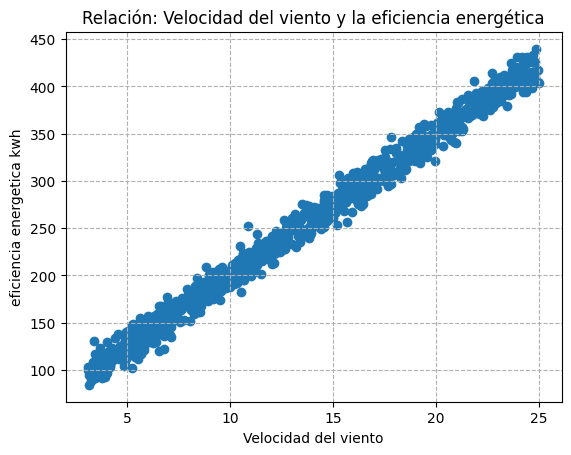

In [22]:
# Visualización de la relación entre las variables y te lo grafica
plt.scatter(df['Velocidad_Viento_ms'], df['Eficiencia_Energetica_kWh'])
plt.title('Relación: Velocidad del viento y la eficiencia energética')
plt.xlabel('Velocidad del viento') #etiqueta
plt.ylabel('eficiencia energetica kwh') #etiqueta
plt.grid(True, linestyle='--')
plt.show() #Sirve para mostrar la grafica

In [23]:
# Selección de variables

# X es la variable independiente
X = df[['Velocidad_Viento_ms']]
#  y es la variable objetivo
y = df['Eficiencia_Energetica_kWh']

In [24]:
# División de datos (Entrenamiento y prueba)

# Importamos la librería para la separación
from sklearn.model_selection import train_test_split

In [25]:
# Reservamos el 30% de los datos para probar el modelo al final

### -----> CAMBIAR en random_state=0 el 0 por su número de MATRÍCULA
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1068493)

# **Fase 4: Entrenamiento del Modelo (Scikit-Learn)**

In [26]:
# Importamos la librería para la regresión lineal
from sklearn.linear_model import LinearRegression

In [27]:
# Creación del Modelo
LR = LinearRegression()

In [28]:
# Entrenamiento del Modelo le damos los datos para que pueda aprender
LR.fit(X_train, y_train)

LinearRegression()

In [29]:
# Verificamos el ajuste a los datos de entrenamiento tratar de que se acerque a 1 para que su predicción sea más asertada
LR.score(X_train, y_train)

0.988960281515946

Cálculo de los coeficientes de la ecuación de regresión lineal

In [30]:
# Pendiente de la recta
b1 = LR.coef_
print("Pendiente de la recta \n m =", b1)

Pendiente de la recta 
 m = [14.95553102]


In [31]:
# Intersección con el eje y
b0 = LR.intercept_
print("Intersección con el eje y \n b =", b0)

Intersección con el eje y 
 b = 50.73412035299879


# **Fase 5: Validación y Predicción**

In [32]:
# Importamos la librería para la métrica r^2
from sklearn.metrics import r2_score

In [33]:
# Cálculo de r^2
# Una puntuación de 1 indica un ajuste perfecto
# Una puntuación de 0 indica que el modelo no es apto para predecir la variable objetivo

#Tiene que ser muy parecido al LR. Score de entrenamiento

r2 = LR.score(X_test, y_test)
print("R^2 score =", r2)

R^2 score = 0.9897958704310196


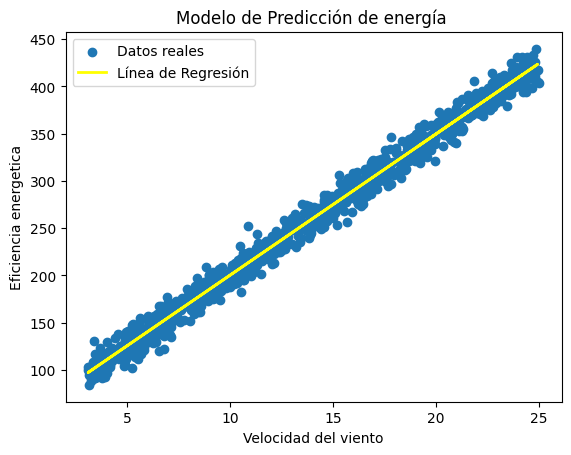

In [37]:
# Visualización del Modelo Resultante
pred = LR.predict(X_test)
plt.scatter(X, y, label='Datos reales')
plt.plot(X_test, pred, color='yellow', linewidth=2, label='Línea de Regresión')
plt.title('Modelo de Predicción de energía ')
plt.xlabel('Velocidad del viento')
plt.ylabel('Eficiencia energetica')
plt.legend()
plt.show()

# **Fase 6: Hacia el Despliegue (Streamlit)**

El objetivo de Streamlit es permitir que cualquier persona (un biólogo marino, un político o un ciudadano) use nuestro modelo de IA sin necesidad de saber programar.

In [38]:
#Se cambia en cada trabajo para crear un nuevo archivo de pyton
%%writefile Corales.py
# Importar librerías necearias
import numpy as np
import streamlit as st
import pandas as pd

# Insertamos título
st.write(''' # ODS 7: Energía Asequible y No Contaminante''')
# Insertamos texto con formato
st.markdown("""
Esta aplicación utiliza **Machine Learning** para predecir el impacto del nivel del viento en la generación de energía **ODS 7: Energía Asequible y No Contaminante**.
""")
# Insertamos una imagen
st.image("enes.jpg", caption="Eficiencia energética de acuerdo al nivel del viento.")


# Definimos cómo ingresará los datos el usuario
# Usaremos un deslizador
st.sidebar.header("Velocidad del viento")
# Definimos los parámetros de nuestro deslizador:
  # Límite inferior: 24°C. Es el límite inferior donde los arrecifes tropicales suelen estar cómodos
  # Límite superior: 35°C. La mayoría de los corales mueren o se blanquean totalmente mucho antes de llegar a esa temperatura
  # Valor inicial: 28°C. En muchos arrecifes, a partir de los 28.5°C o 29°C comienza el estrés térmico severo
temp_input = st.sidebar.slider("Velocidad del viento en m/s",0,30)

# Cargamos el archivo con los datos (.csv)
df =  pd.read_csv('ene2.csv', encoding='latin-1')
# Seleccionamos las variables
X = df[['Velocidad_Viento_ms']]
y = df['Eficiencia_Energetica_kWh']

# Creamos y entrenamos el modelo
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0)
LR = LinearRegression()
LR.fit(X_train,y_train)

# Hacemos la predicción con el modelo y la temperatura seleccionada por el usuario
b1 = LR.coef_
b0 = LR.intercept_
prediccion = b0 + b1[0]*temp_input

# Presentamos loa resultados
st.subheader('Eficiencia energetica')
st.write(f'El nivel de energía es: {prediccion:.2f} Wkh')

if prediccion < 500:
        st.success("Eficiencia baja")
elif prediccion < 3000:
        st.warning("Alta eficiencia")
else:
        st.error("Muy alta eficiencia")

Writing Corales.py
